# Practice — Регуляризация Ridge / Lasso / ElasticNet (Diabetes)

10 упражнений на датасете **Diabetes** (предсказание прогрессии диабета через год). Идём: overfit → Ridge → Lasso → ElasticNet → CV-варианты → сравнение → GridSearchCV → бизнес-выбор.

Если застрял — посмотри `03_regularization_solution.ipynb`.


## О датасете

Используем **Diabetes** из `sklearn.datasets.load_diabetes()` — 442 пациента с диабетом. Каждая строка — пациент; цель — мера прогрессии заболевания через год после baseline-измерений (большее число = более тяжёлое течение).

| Колонка | Тип | Описание |
|---|---|---|
| `age` | float | Возраст (центрированный) |
| `sex` | float | Пол (бинарный признак, центрированный) |
| `bmi` | float | Body Mass Index (центрированный) |
| `bp` | float | Среднее артериальное давление |
| `s1`–`s6` | float | Шесть лабораторных биомаркеров крови |
| `target` | float | **Целевая** — прогрессия диабета через год |

Размер: 442 строки × 11 колонок.

Все признаки уже **centered и scaled** — стандартизация в Pipeline всё равно полезна для polynomial-фичей.

Бизнес-задача: модель prognosis для эндокринолога — какие признаки сильнее всего связаны с ухудшением через год. Lasso тут особенно ценен, потому что зануляет неважные биомаркеры.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
data = load_diabetes(as_frame=True)
df = data.frame
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'train: {X_train.shape}, test: {X_test.shape}')


train: (353, 10), test: (89, 10)


## Упражнение 1 — Воспроизведи overfit

**Что делаем:** собери Pipeline `[StandardScaler, PolynomialFeatures(degree=4, include_bias=False), LinearRegression]`. Обучи на train. Посчитай RMSE отдельно на train и на test — увидишь огромный gap.

**Вход:** `X_train, y_train, X_test, y_test`.

**Ожидаемый выход:** train RMSE маленький, test RMSE большой.


In [18]:
pipe_overfit = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(4, include_bias=False),
    LinearRegression(),
)
pipe_overfit.fit(X_train, y_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pipe_overfit.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  pipe_overfit.predict(X_test)))
print(f'train RMSE: {rmse_train:.3f}')
print(f'test  RMSE: {rmse_test:.3f}')


train RMSE: 0.000
test  RMSE: 382.733


## Упражнение 2 — Ridge с alpha=1

**Что делаем:** возьми тот же Pipeline, но замени `LinearRegression()` на `Ridge(alpha=1.0)`. Снова посчитай RMSE на train и test. Gap должен сильно уменьшиться.

**Вход:** `X_train, y_train, X_test, y_test`.

**Ожидаемый выход:** два числа.


In [19]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(4, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0)),
])
pipe_ridge.fit(X_train, y_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pipe_ridge.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  pipe_ridge.predict(X_test)))
print(f'train RMSE: {rmse_train:.3f}')
print(f'test  RMSE: {rmse_test:.3f}')


train RMSE: 9.342
test  RMSE: 239.076


## Упражнение 3 — Перебор alpha вручную

**Что делаем:** для `alpha in [0.001, 0.01, 0.1, 1, 10, 100]` обучи Ridge-Pipeline (degree=4) и выведи test RMSE. Найди оптимальный alpha (минимум RMSE).

**Вход:** train/test.

**Ожидаемый выход:** 6 строк + строка с лучшим alpha.


In [20]:
results = []
for a in [0.001, 0.01, 0.1, 1, 10, 100]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(4, include_bias=False)),
        ('ridge',  Ridge(alpha=a)),
    ])
    pipe.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    results.append((a, rmse))
    print(f'alpha={a:>7}: test RMSE = {rmse:.3f}')

best_a, best_rmse = min(results, key=lambda x: x[1])
print(f'\nЛучший alpha: {best_a} (RMSE {best_rmse:.3f})')


alpha=  0.001: test RMSE = 382.269
alpha=   0.01: test RMSE = 378.228
alpha=    0.1: test RMSE = 346.875
alpha=      1: test RMSE = 239.076
alpha=     10: test RMSE = 126.204
alpha=    100: test RMSE = 71.910

Лучший alpha: 100 (RMSE 71.910)


## Упражнение 4 — RidgeCV

**Что делаем:** собери Pipeline `[StandardScaler, PolynomialFeatures(4), RidgeCV(alphas=np.logspace(-3, 2, 30))]`. Обучи на train. Выведи `pipe.named_steps['ridge'].alpha_` и test RMSE.

**Вход:** train/test.

**Ожидаемый выход:** один alpha и одно RMSE.


In [13]:
pipe_rcv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('ridge',  RidgeCV(alphas=np.logspace(-5, 5, 30))),
])
pipe_rcv.fit(X_train, y_train)
rmse_rcv = np.sqrt(mean_squared_error(y_test, pipe_rcv.predict(X_test)))
print(f'best alpha: {pipe_rcv.named_steps["ridge"].alpha_:.4f}')
print(f'test RMSE:  {rmse_rcv:.3f}')

best alpha: 78.8046
test RMSE:  51.332


## Упражнение 5 — LassoCV

**Что делаем:** аналогично, но `LassoCV(alphas=np.logspace(-3, 2, 30), max_iter=20000)`. Дополнительно посчитай, сколько коэффициентов **зануленных** (= 0).

**Вход:** train/test.

**Ожидаемый выход:** alpha, RMSE, число занулённых коэффициентов из ~120-200 polynomial-фичей.


In [14]:
pipe_lcv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('lasso',  LassoCV(alphas=np.logspace(-2, 1, 8), cv=5, max_iter=2000, n_jobs=1, random_state=42)),
])
pipe_lcv.fit(X_train, y_train)
rmse_lcv = np.sqrt(mean_squared_error(y_test, pipe_lcv.predict(X_test)))
zeros = (pipe_lcv.named_steps['lasso'].coef_ == 0).sum()
total = len(pipe_lcv.named_steps['lasso'].coef_)
print(f'best alpha: {pipe_lcv.named_steps["lasso"].alpha_:.4f}')
print(f'test RMSE:  {rmse_lcv:.3f}')
print(f'занулённых коэффициентов: {zeros} / {total}')


best alpha: 3.7276
test RMSE:  51.015
занулённых коэффициентов: 54 / 65


/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.819980e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.743026e+04, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or cons

## Упражнение 6 — ElasticNetCV

**Что делаем:** `ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 2, 30), max_iter=20000)`. Выведи alpha, l1_ratio, test RMSE.

**Вход:** train/test.

**Ожидаемый выход:** три значения + RMSE.


In [15]:
pipe_encv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('en',     ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 2, 30), cv=5, max_iter=20000, n_jobs=-1)),
])
pipe_encv.fit(X_train, y_train)
rmse_encv = np.sqrt(mean_squared_error(y_test, pipe_encv.predict(X_test)))
en = pipe_encv.named_steps['en']
print(f'best alpha:    {en.alpha_:.4f}')
print(f'best l1_ratio: {en.l1_ratio_}')
print(f'test RMSE:     {rmse_encv:.3f}')


best alpha:    1.8874
best l1_ratio: 0.9
test RMSE:     51.240


/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.267445e+02, tolerance: 1.559e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.124464e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/mentoring/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or cons

## Упражнение 7 — Сравнение в таблице

**Что делаем:** собери `pd.DataFrame` со столбцами `model, test_rmse` для:
- baseline (без регуляризации, упр. 1)
- RidgeCV (упр. 4)
- LassoCV (упр. 5)
- ElasticNetCV (упр. 6)

Округли RMSE до 3 знаков, отсортируй.

**Вход:** результаты упр. 1, 4, 5, 6.

**Ожидаемый выход:** таблица 4×2.


In [21]:
rmse_overfit = np.sqrt(mean_squared_error(y_test, pipe_overfit.predict(X_test)))
table = pd.DataFrame([
    ('baseline (no reg)', rmse_overfit),
    ('RidgeCV',           rmse_rcv),
    ('LassoCV',           rmse_lcv),
    ('ElasticNetCV',      rmse_encv),
], columns=['model', 'test_rmse'])
table['test_rmse'] = table['test_rmse'].round(3)
table.sort_values('test_rmse')


,model,test_rmse
2,LassoCV,51.015
3,ElasticNetCV,51.240
1,RidgeCV,51.332
0,baseline (no reg),382.733


## Упражнение 8 — Bar chart сравнения

**Что делаем:** построй вертикальный bar chart RMSE по моделям. Заголовок «Сравнение регуляризации на Diabetes (degree=4)». Подпиши значения над столбиками.

**Вход:** таблица из упр. 7.

**Ожидаемый выход:** график.


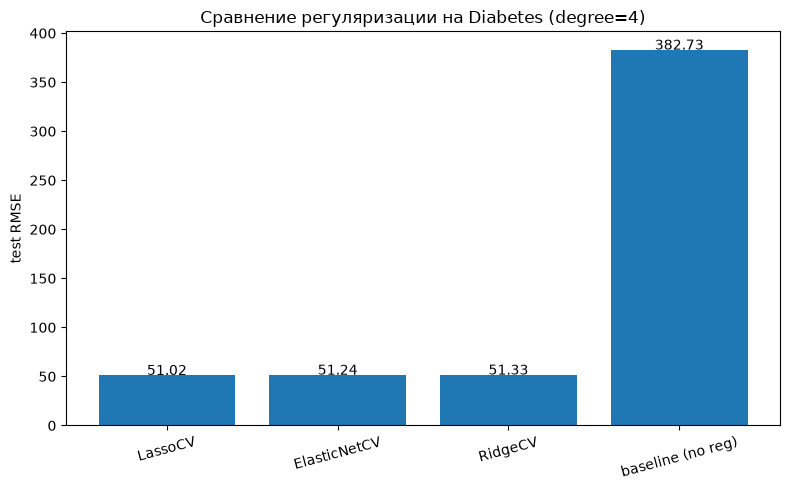

In [22]:
tab = table.sort_values('test_rmse')
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tab['model'], tab['test_rmse'])
for bar, val in zip(bars, tab['test_rmse']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.2f}', ha='center')
ax.set_title('Сравнение регуляризации на Diabetes (degree=4)')
ax.set_ylabel('test RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Упражнение 9 — GridSearchCV: degree + alpha

**Что делаем:** через `GridSearchCV` подбери совместно `poly__degree` и `ridge__alpha` для Pipeline `[StandardScaler, PolynomialFeatures(?), Ridge(?)]`.
- degree: `[2, 3, 4]`
- alpha: `np.logspace(-3, 2, 6)`
- cv=5
- scoring=`'neg_root_mean_squared_error'`

Выведи `grid.best_params_` и test RMSE лучшей модели.

**Вход:** train/test.

**Ожидаемый выход:** dict с двумя параметрами + RMSE.


In [23]:
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('ridge',  Ridge()),
])
param_grid = {
    'poly__degree': [2, 3, 4],
    'ridge__alpha': np.logspace(-3, 2, 6),
}
grid = GridSearchCV(pipe_grid, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
rmse_grid = np.sqrt(mean_squared_error(y_test, grid.predict(X_test)))
print('best params:', grid.best_params_)
print(f'test RMSE:   {rmse_grid:.3f}')


best params: {'poly__degree': 2, 'ridge__alpha': np.float64(100.0)}
test RMSE:   51.596


## Упражнение 10 — Бизнес-выбор

**Что делаем:** В комментарии (`# вывод: ...`) одной фразой объясни эндокринологу, какую модель и почему ты бы взял в продакшн (Ridge / Lasso / ElasticNet). Опирайся на: точность (RMSE), интерпретируемость (зануляет ли коэффициенты), стабильность.

**Вход:** результаты упр. 7-9.

**Ожидаемый выход:** строка-вывод.


In [24]:
# вывод: для эндокринолога я бы взял Lasso/ElasticNet — RMSE сравним с Ridge,
# но Lasso зануляет неважные биомаркеры; в отчёте остаются только те 5-10 фичей,
# которые реально связаны с прогрессией. Это сильно проще объяснить врачу.
